# Tutorial for SNR calculations for an emission line

Hello! Here is a tutorial for the SNR calculations for a singular emission line. Here, you will make an emission line by inputting in its FWHM, flux, and centre frequency. Then, this notebook will walk you through turning this signal into photon counts to calculate the SNR for some given exposure time.

First, we need to import some libraries:

In [1]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


The following is just so you can use the functions in this folder as well as the libraries we have downloaded.

In [4]:
import sys
sys.path.append('..')

import src as src
import numpy as np
import matplotlib.pyplot as plt

# Creating the emission line

Now, here is where you make your inputs for an emission line. The "l" array is the desired array of wavelengths in micron. The output is a Gaussian where the area is the inputted flux. You can also include a redshift "z," here I have just used z=0.

The units of the centre frquency is micron, flux is erg/cm^2/s, and fwhm is km/s.

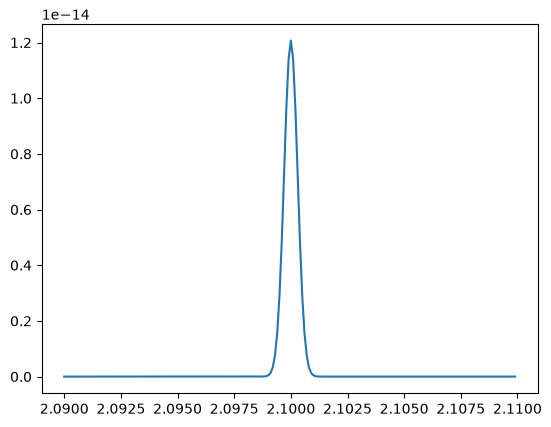

In [5]:
centre = 2.1
flux = 9.0e-18
fwhm = 100
l = np.arange(centre-0.01, centre+0.01, 1e-4)
z=0
wvl, signal = src.emission_line_signal(l, flux, fwhm, centre, z)

plt.plot(wvl, signal)
plt.show()

# Binning data and obtaining throughput, sky data, and atmospheric transmission

Very nice! We then need to rebin this emission line according to the dispersion of MIRMOS. I have made a nice and handy function for this that you can just call. The only thing about this function is that it returns an array for all bands. In this case, YJK bands are empty so this is just plotting the H band data.

However, before I do that, let's also look at the sky data for this range of wavelengths. You can get this data from the same function mentioned above.

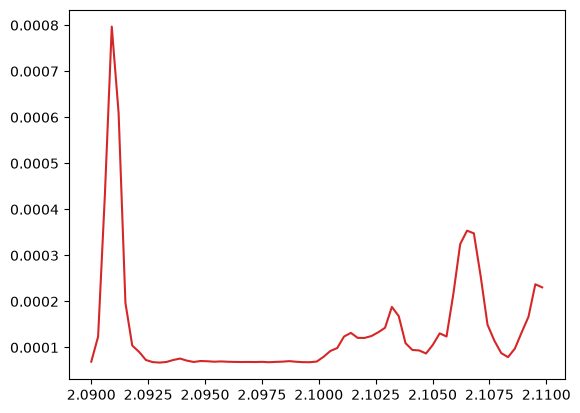

In [6]:
wvl_full, signal_full, thpt, sky, atm = src.bin_signal_thp_atm_sky_data(wvl, signal)

for i in range(len(wvl_full)):
    #plt.plot(wvl_full[i], signal_full[i])
    #plt.plot(wvl_full, thpt)
    plt.plot(wvl_full[i], sky[i])

Cool. Now, let's apply the throughput and atmospheric transmission to our signal. There is also a function for this! And one that will also apply the throughput to the sky data. Once you do that, make your variables for telescope area and slit width and angular extent (in arcsec) to turn this data into photon counts per pixel.

We do this because eventually that is needed for the SNR calculations.

# Getting the signal and sky data in photon counts per pixel

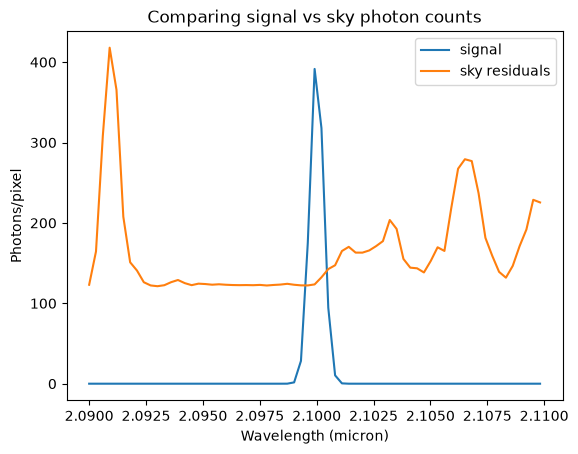

In [7]:
signal_final = src.apply_thpt_atm_to_signal(wvl_full, signal_full, thpt, atm)
sky_final = src.apply_thpt_to_sky(wvl_full, sky, thpt)

area = 0.93 /4* np.pi*650**2
signal_per_pixel = src.calculate_signal_to_photon_counts(wvl_full, signal_final, area)
sky_per_pixel = src.calculate_sky_to_photon_counts(sky_final, area, slit_width=0.84, angular_extent=0.8)

exp_time = 1000 #seconds

plt.plot(wvl_full[3], signal_per_pixel[3]*exp_time, label = "signal")
plt.plot(wvl_full[3], np.sqrt(sky_per_pixel[3]*exp_time), label = "sky residuals")

plt.ylabel("Photons/pixel")
plt.xlabel("Wavelength (micron)")

plt.legend()

plt.title("Comparing signal vs sky photon counts")
plt.show()


I have also included an exposure time variable. You don't need to do that and can do things in terms of "photons/pixel/second" if you please. Another thing to note, in the above cell I have used the square root of the sky data. This is the "sky residuals," which is the noise due to the sky data. Since the sky photon counts themselves are very high, this is the convention to compare the signal and the sky.

# Calculating SNR per pixel

Now, we can go to calculating the SNR! Provided all the inputs: signal data, sky data, exposure time (default is 1000), angular extent (default is 0.84), read noise (default is 16 per pixel), and Fowler sampling (default is 16), you can calculate the SNR per pixel across the wavelengths specified in the beginning of the notebook.

If you want to do this across multiple bands, you need to run this function multiple times and change the read noise if it changes per band. If all the parameters stay the same throughout all bands, then you can do it in one line.

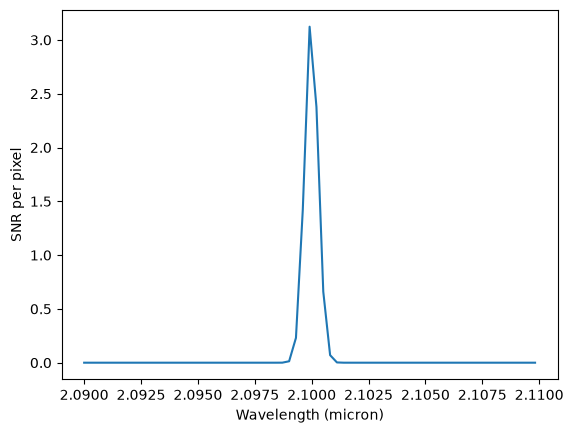

In [9]:
snr_per_pixel = src.calculate_signal_to_noise(signal_per_pixel[3], sky_per_pixel[3]) # just going to use the defaults
# make sure the data is photons per pixel!

plt.plot(wvl_full[3], snr_per_pixel)
plt.ylabel("SNR per pixel")
plt.xlabel("Wavelength (micron)")

plt.show()